<a href="https://colab.research.google.com/github/cassimshayck/mini-gpt/blob/main/03_kfac_mlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_2247/3083579353.py:50: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss_fn(model(X[0:1]), Y[0:1]).backward()
/tmp/ipykernel_2247/3083579353.py:66: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss_fn(model(X[i:i+1]), y_s[i:i+1]).backward()
/tmp/ipykernel_2247/3083579353.py:83: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for mo

tensor(0.)
tensor(0.)
{'0.weight': (0, 8), '0.bias': (8, 12), '2.weight': (12, 24), '2.bias': (24, 27)}
0.weight 2.2243363857269287
2.weight 0.061139244586229324
6.069918185858114e-07


/tmp/ipykernel_2247/3083579353.py:116: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss_fn(model(X[i:i+1]), labels[i:i+1]).backward()
/tmp/ipykernel_2247/3083579353.py:146: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss_fn(model(X), Y).backward()
/tmp/ipykernel_2247/3083579353.py:170: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more d

0.09277626872062683


/tmp/ipykernel_2247/3083579353.py:188: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss_fn(model(X), Y).backward()
/tmp/ipykernel_2247/3083579353.py:196: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss_fn(model(X[i:i+1]), y_s[i:i+1]).backward()


0.0441242977976799
0.11835785955190659


/tmp/ipykernel_2247/3083579353.py:223: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss_fn(model(X), Y).backward()


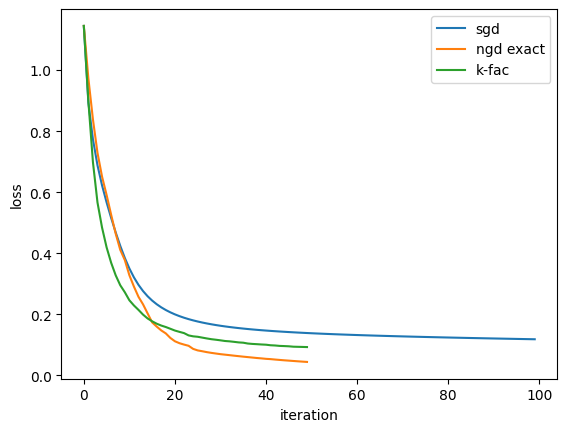

/tmp/ipykernel_2247/3083579353.py:238: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss_fn(model(X), labels).backward()          # ONE backward on the 120 points


tensor(9.5367e-07) tensor(2.9802e-08)
tensor(1.4901e-07) tensor(7.4506e-09)


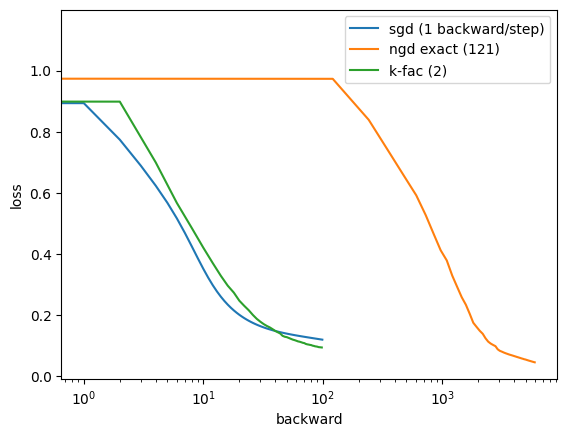

In [ ]:
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

torch.manual_seed(12)
A_ = torch.randn(40, 2) * 0.7 + torch.tensor([2, 0])
B_ = torch.randn(40, 2) * 0.7
C_ = torch.randn(40, 2) * 0.7 + torch.tensor([1.5, 3])
X = torch.cat([A_, B_, C_], dim=0)

Z = torch.zeros(40, dtype=torch.long)
O = torch.ones(40, dtype=torch.long)
T = torch.full((40,), 2)
Y = torch.cat([Z, O, T], dim=0)

model = nn.Sequential(nn.Linear(2, 4), nn.Tanh(), nn.Linear(4, 3))
loss_fn = nn.CrossEntropyLoss()
D = sum(p.numel() for p in model.parameters())
N = len(X)
layers_wm = [model[0], model[2]]
#print(D, N)

# starting point shared by K-FAC, exact NGD and SGD
etat0 = copy.deepcopy(model.state_dict())




A_store = {} #hooks
G_store = {}


def save_a(module, inp, out):
    A_store[module] = inp[0].detach()  # catching the a's, hooking (a not kept)


def save_g(module, grad_in, grad_out):
    G_store[module] = grad_out[0].detach()  # catching the g's, hooking (g not kept)


handles = []
for layer in layers_wm:
    handles.append(layer.register_forward_hook(save_a))
    handles.append(layer.register_full_backward_hook(save_g))
#print(len(model[0]._forward_hooks))  # must be 1, otherwise restart the kernel

model.zero_grad()
loss_fn(model(X[0:1]), Y[0:1]).backward()

a = A_store[model[0]][0]
g = G_store[model[0]][0]
#print(a.shape, g.shape)
print((torch.outer(g, a) - model[0].weight.grad).abs().max())  # ok, we have grad_W = g a^T for first layer
print((torch.kron(g, a) - model[0].weight.grad.flatten()).abs().max())  # 0: the order is kron(g, a) with those results


#Kronecker factors (weights only)
A = {layer: torch.zeros(layer.in_features, layer.in_features) for layer in layers_wm}
G = {layer: torch.zeros(layer.out_features, layer.out_features) for layer in layers_wm}
y_s = torch.multinomial(torch.softmax(model(X), dim=1), 1).squeeze(1)

for i in range(N):
    model.zero_grad()
    loss_fn(model(X[i:i+1]), y_s[i:i+1]).backward()
    for layer in layers_wm:
        a = A_store[layer][0]
        g = G_store[layer][0]
        A[layer] += torch.outer(a, a)  # 1D dimension required
        G[layer] += torch.outer(g, g)  # 1D dimension too

for layer in layers_wm:
    A[layer] /= N
    G[layer] /= N


#Comparison with the exact Fisher
# Fisher building now as the prevent codes
F = torch.zeros(D, D)
for i in range(N):
    model.zero_grad()
    loss_fn(model(X[i:i+1]), y_s[i:i+1]).backward()
    M = torch.cat([p.grad.flatten() for p in model.parameters()])
    F += torch.outer(M, M)
F /= N

# where each parameter tensor sits in the flat vector of size D
offsets = {}
k = 0
for name, p in model.named_parameters():
    offsets[name] = (k, k + p.numel())
    k += p.numel()
print(offsets)  # 0.weight (0,8), 0.bias (8,12), 2.weight (12,24), 2.bias (24,27)
# need this to simplify the code below

# K-FAC, E(g*g^T kron a*a^T) ""="" E(g*g^T) kron E(a*a^T)
for name, layer in [('0.weight', model[0]), ('2.weight', model[2])]:
    d, f = offsets[name]
    F_bloc = F[d:f, d:f]
    K = torch.kron(G[layer], A[layer])
    print(name, ((K - F_bloc).norm() / F_bloc.norm()).item())

""" after tanh, results much more precise, maybe due to the homogeneity of the data (in [-1,1]),
so the problem would be the first layer only ? Cov(||a||,||g||) high at the begining maybe"""


#K-FAC test


def kfac_factors(labels):
    A = {layer: torch.zeros(layer.in_features + 1, layer.in_features + 1) for layer in layers_wm}  # +1 for bias
    G = {layer: torch.zeros(layer.out_features, layer.out_features) for layer in layers_wm}
    for i in range(N):
        model.zero_grad()
        loss_fn(model(X[i:i+1]), labels[i:i+1]).backward()
        for layer in layers_wm:
            a = torch.cat([A_store[layer][0], torch.ones(1)])  # counting bias now, a = (a|1)
            g = G_store[layer][0]
            A[layer] += torch.outer(a, a)
            G[layer] += torch.outer(g, g)
    for layer in layers_wm:
        A[layer] /= N
        G[layer] /= N
    return A, G


def kfac_step(A, G, eta, lam):
    with torch.no_grad():
        for layer in layers_wm:
            V = torch.cat([layer.weight.grad, layer.bias.grad.unsqueeze(1)], dim=1)  # [grad_W | grad_b]
            A_inv = torch.linalg.inv(A[layer] + lam * torch.eye(A[layer].shape[0]))
            G_inv = torch.linalg.inv(G[layer] + lam * torch.eye(G[layer].shape[0]))
            Step = -eta * G_inv @ V @ A_inv
            layer.weight += Step[:, :-1]
            layer.bias += Step[:, -1]


eta, lam = 0.1, 1e-3

# check: G^-1 V A^-1 is the same as (G kron A)^-1 applied to vec(V)
model.load_state_dict(etat0)
y_s = torch.multinomial(torch.softmax(model(X), dim=1), 1).squeeze(1)
A, G = kfac_factors(y_s)
model.zero_grad()
loss_fn(model(X), Y).backward()
layer = model[0]
Ad = A[layer] + lam * torch.eye(A[layer].shape[0])
Gd = G[layer] + lam * torch.eye(G[layer].shape[0])
V = torch.cat([layer.weight.grad, layer.bias.grad.unsqueeze(1)], dim=1)
version_kron = torch.linalg.inv(torch.kron(Gd, Ad)) @ V.flatten()
version_matrice = (torch.linalg.inv(Gd) @ V @ torch.linalg.inv(Ad)).flatten()
print(((version_kron - version_matrice).norm() / version_kron.norm()).item())


# K-FAC (really)
model.load_state_dict(etat0)
torch.manual_seed(12)
losses_kfac = []

for it in range(50):
    losses_kfac.append(loss_fn(model(X), Y).item())

    # 1. metric: labels sampled from the model
    y_s = torch.multinomial(torch.softmax(model(X), dim=1), 1).squeeze(1)
    A, G = kfac_factors(y_s)

    # 2. direction: real labels, AFTER the factors (their loop overwrites .grad)
    model.zero_grad()
    loss_fn(model(X), Y).backward()

    # 3. step
    kfac_step(A, G, eta, lam)

print(losses_kfac[-1])


# exact NGD, same starting point
model.load_state_dict(etat0)
torch.manual_seed(12)
losses_ngd = []

for it in range(50):
    losses_ngd.append(loss_fn(model(X), Y).item())

    # 1. direction
    model.zero_grad()
    loss_fn(model(X), Y).backward()
    grad = torch.cat([p.grad.flatten() for p in model.parameters()])

    # 2. metric
    y_s = torch.multinomial(torch.softmax(model(X), dim=1), 1).squeeze(1)
    Fmat = torch.zeros(D, D)
    for i in range(N):
        model.zero_grad()
        loss_fn(model(X[i:i+1]), y_s[i:i+1]).backward()
        g = torch.cat([p.grad.flatten() for p in model.parameters()])
        Fmat += torch.outer(g, g)
    Fmat /= N

    # 3. step
    d = -eta * torch.linalg.solve(Fmat + lam * torch.eye(D), grad)

    # 4. uploading
    with torch.no_grad():
        k = 0
        for p in model.parameters():
            n = p.numel()
            p += d[k:k+n].view_as(p)
            k += n

print(losses_ngd[-1])


# SGD, same starting point
model.load_state_dict(etat0)
opt = torch.optim.SGD(model.parameters(), lr=1.0)  # optimizer created AFTER the reset
losses_sgd = []

for i in range(100): # same "budget" as K-FAC with 2 backwards below
    losses_sgd.append(loss_fn(model(X), Y).item())
    opt.zero_grad()
    loss_fn(model(X), Y).backward()
    opt.step()

print(losses_sgd[-1])


plt.plot(losses_sgd, label="sgd")
plt.plot(losses_ngd, label="ngd exact")
plt.plot(losses_kfac, label="k-fac")
plt.xlabel("iteration"); plt.ylabel("loss"); plt.legend(); plt.show()

#121 backward, too much, now trying to do 1 backward like SGD:

def kfac_factors_batch(labels):
    model.zero_grad()
    loss_fn(model(X), labels).backward()          # ONE backward on the 120 points
    A, G = {}, {}
    for layer in layers_wm:
        a = A_store[layer]                         # (N, n_in): one row per point
        a = torch.cat([a, torch.ones(N, 1)], dim=1)  # (N, n_in+1): bias
        g = G_store[layer] * N                     # (N, n_out): undo the 1/N of the mean loss
        A[layer] = a.T @ a / N
        G[layer] = g.T @ g / N
    return A, G


y_s = torch.multinomial(torch.softmax(model(X), dim=1), 1).squeeze(1)
A1, G1 = kfac_factors(y_s)          # loop: 120 backward
A2, G2 = kfac_factors_batch(y_s)    # batch: 1 backward
for layer in layers_wm:
    print((A1[layer] - A2[layer]).abs().max(), (G1[layer] - G2[layer]).abs().max())


plt.plot(np.arange(len(losses_sgd))  * 1,   losses_sgd,  label="sgd (1 backward/step)")
plt.plot(np.arange(len(losses_ngd))  * 121, losses_ngd,  label="ngd exact (121)")
plt.plot(np.arange(len(losses_kfac)) * 2,   losses_kfac, label="k-fac (2)")
plt.xscale("log"); plt.xlabel("backward"); plt.ylabel("loss"); plt.legend(); plt.show()






A and G built from one batched backward (hooks give per-point a and g; grad_out * N
  undoes the mean). Matches the loop version to 1e-7.
Cost per step: SGD 1, K-FAC 2, exact NGD 121 backward.
At ~100 backward: K-FAC ~0.1, exact NGD still ~1.0. K-FAC keeps the NGD gain per
  iteration at near-SGD cost.

Finally, for lm =1.0, K-FAC changed "nothing" compared to SGD, maybe beacause the MLP is too small to the differences here, but for lm=0.1: K-FAC clear !
